In [71]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# STEP 2: Importing Required Libraries
# ============================================================

# Data manipulation and numerical processing
import pandas as pd
import numpy as np

# File and path handling
import glob
import os

# Creating graphs and visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting and scaling the network traffic data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine-learning anomaly detection algorithms
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Model evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# Used to measure model training and prediction time
import time

# Hiding unnecessary warning messages to keep notebook output clean
import warnings
warnings.filterwarnings("ignore")

# Fixed random seed makes the experiment reproducible
RANDOM_STATE = 42

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [4]:
# ============================================================
# STEP 3: Loading the CICIDS2017 Dataset
# ============================================================

# Finding all CSV files inside the MachineLearningCVE folder.
csv_files = sorted(glob.glob("MachineLearningCVE/*.csv"))

# Displaying the number of CSV files found.
print(f"Number of CSV files found: {len(csv_files)}")

# Displaying each filename to confirm that the dataset files have been located correctly.
print("\nFiles found:")
for file in csv_files:
    print("-", os.path.basename(file))

# Stopping here with a clear error if the folder/path is incorrect.
if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files were found. Check that the MachineLearningCVE "
        "folder is in the same directory as this notebook."
    )

# Loading each CSV file and combine them into one DataFrame.
# ignore_index=True creates a new continuous row index after combining.
df = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in csv_files],
    ignore_index=True
)

# Removing unnecessary spaces from column names.
df.columns = df.columns.str.strip()

# Displayings basic information about the combined dataset.
print("\nDataset loaded successfully.")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

# Displaying the first five records to verify the data.
display(df.head())

Number of CSV files found: 8

Files found:
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- Friday-WorkingHours-Morning.pcap_ISCX.csv
- Monday-WorkingHours.pcap_ISCX.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- Tuesday-WorkingHours.pcap_ISCX.csv
- Wednesday-workingHours.pcap_ISCX.csv

Dataset loaded successfully.
Total rows: 2,830,743
Total columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
# ============================================================
# STEP 4: Inspecting Dataset Labels and Data Quality
# ============================================================

# Removing leading/trailing spaces from the Label values.
# This prevents values such as " BENIGN" and "BENIGN" from being treated as different classes.
df["Label"] = df["Label"].astype(str).str.strip()


# 1. Displaying all traffic/attack categories

print("Traffic categories in CICIDS2017:\n")

label_counts = df["Label"].value_counts()

for label, count in label_counts.items():
    print(f"{label}: {count:,}")

print(f"\nNumber of unique traffic categories: {df['Label'].nunique()}")



# 2. Checking for missing values

missing_values = df.isnull().sum().sum()

print("\nData Quality Check")
print("------------------")
print(f"Missing values: {missing_values:,}")



# 3. Checking for infinite values in numerical columns

# Selecting only numerical features before checking for infinity.
numeric_columns = df.select_dtypes(include=[np.number]).columns

infinite_values = np.isinf(df[numeric_columns]).sum().sum()

print(f"Infinite values: {infinite_values:,}")



# 4. Checking for duplicate network-flow records

duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")



# 5. Display feature data types

print("\nColumn data types:")
print(df.dtypes.value_counts())

Traffic categories in CICIDS2017:

BENIGN: 2,273,097
DoS Hulk: 231,073
PortScan: 158,930
DDoS: 128,027
DoS GoldenEye: 10,293
FTP-Patator: 7,938
SSH-Patator: 5,897
DoS slowloris: 5,796
DoS Slowhttptest: 5,499
Bot: 1,966
Web Attack � Brute Force: 1,507
Web Attack � XSS: 652
Infiltration: 36
Web Attack � Sql Injection: 21
Heartbleed: 11

Number of unique traffic categories: 15

Data Quality Check
------------------
Missing values: 1,358
Infinite values: 4,376
Duplicate rows: 308,381

Column data types:
int64      54
float64    24
object      1
Name: count, dtype: int64


In [8]:
# ============================================================
# STEP 5: Cleaning the CICIDS2017 Dataset
# ============================================================

# Storing the original number of rows to report how many records are removed during the cleaning process.
original_rows = len(df)

print(f"Rows before cleaning: {original_rows:,}")



# 1. Cleaning the traffic labels

# Removing leading and trailing spaces from all labels.
df["Label"] = df["Label"].astype(str).str.strip()

# Replacing the encoding character found in some Web Attack labels to make the attack names easier to read in later tables and graphs.
df["Label"] = df["Label"].str.replace("�", "-", regex=False)

# Removing repeated spaces that may remain after fixing the labels.
df["Label"] = df["Label"].str.replace(r"\s+", " ", regex=True)



# 2. Replacing infinite values

# Machine-learning algorithms cannot process positive or negative infinity directly. Converting them to NaN so they can be removed together with the existing missing values.
df.replace([np.inf, -np.inf], np.nan, inplace=True)



# 3. Removing rows containing missing values

rows_before_missing = len(df)

df.dropna(inplace=True)

rows_removed_missing = rows_before_missing - len(df)



# 4. Removing duplicate network-flow records

rows_before_duplicates = len(df)

df.drop_duplicates(inplace=True)

rows_removed_duplicates = rows_before_duplicates - len(df)


# Resetting the row index after removing records.
df.reset_index(drop=True, inplace=True)



# 5. Displaying cleaning summary

print("\nCleaning Summary")
print("----------------")
print(f"Rows removed due to missing/infinite values: {rows_removed_missing:,}")
print(f"Duplicate rows removed: {rows_removed_duplicates:,}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Total rows removed: {original_rows - len(df):,}")



# 6. Verifying that the cleaned dataset contains no invalid values

remaining_missing = df.isnull().sum().sum()

numeric_columns = df.select_dtypes(include=[np.number]).columns
remaining_infinite = np.isinf(df[numeric_columns]).sum().sum()

print("\nVerification")
print("------------")
print(f"Remaining missing values: {remaining_missing:,}")
print(f"Remaining infinite values: {remaining_infinite:,}")



# 7. Displaying the cleaned traffic categories

print("\nTraffic categories after cleaning:\n")

for label, count in df["Label"].value_counts().items():
    print(f"{label}: {count:,}")

Rows before cleaning: 2,830,743

Cleaning Summary
----------------
Rows removed due to missing/infinite values: 2,867
Duplicate rows removed: 307,078
Rows after cleaning: 2,520,798
Total rows removed: 309,945

Verification
------------
Remaining missing values: 0
Remaining infinite values: 0

Traffic categories after cleaning:

BENIGN: 2,095,057
DoS Hulk: 172,846
DDoS: 128,014
PortScan: 90,694
DoS GoldenEye: 10,286
FTP-Patator: 5,931
DoS slowloris: 5,385
DoS Slowhttptest: 5,228
SSH-Patator: 3,219
Bot: 1,948
Web Attack - Brute Force: 1,470
Web Attack - XSS: 652
Infiltration: 36
Web Attack - Sql Injection: 21
Heartbleed: 11


In [10]:
# ============================================================
# STEP 6: Creating Ground-Truth Labels and Prepare Data Splits
# ============================================================


# 1. Creating a binary ground-truth label

# The original CICIDS2017 labels contain specific attack names.
# For the main anomaly-detection evaluation, I need a
# simple binary label:
#
# 0 = BENIGN (normal network traffic)
# 1 = ATTACK (anomalous/malicious network traffic)
#
# 
# This binary label will NOT be included as an input feature.
# It is retained only so we can evaluate the models later.

df["Binary"] = np.where(df["Label"] == "BENIGN", 0, 1)

print("Binary class distribution:")
print("--------------------------")
print(f"BENIGN (0): {(df['Binary'] == 0).sum():,}")
print(f"ATTACK (1): {(df['Binary'] == 1).sum():,}")


# 2. Separating features from labels

# Removing both Label and Binary from the feature matrix. This prevents the models from seeing the correct answers.
X = df.drop(columns=["Label", "Binary"])

# Verifying that all remaining model features are numerical.
non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nFeature Information")
print("-------------------")
print(f"Number of features: {X.shape[1]}")
print(f"Non-numeric feature columns: {non_numeric_columns}")



# 3. Separating benign and attack traffic

# Benign traffic will be used to establish normal network behaviour.
X_benign = X[df["Binary"] == 0]

# Attack traffic will NOT be used to train the anomaly detectors.
# It is reserved for evaluating whether the models can detect
# previously unseen malicious behaviour.
X_attack = X[df["Binary"] == 1]

# Keeping the original attack names to later calculate detection rates separately for DDoS, PortScan, DoS, etc.
attack_labels = df.loc[df["Binary"] == 1, "Label"]

print("\nTraffic Separation")
print("------------------")
print(f"Benign flows available: {len(X_benign):,}")
print(f"Attack flows available: {len(X_attack):,}")



# 4. Splitting BENIGN traffic into training and testing sets

# 80% of benign traffic is used to learn normal behaviour.
# 20% is held back as unseen benign traffic for evaluation.
#
# The attack traffic remains completely separate and is never included in this benign training split.

X_benign_train, X_benign_test = train_test_split(
    X_benign,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nBenign Train/Test Split")
print("-----------------------")
print(f"Benign training flows: {len(X_benign_train):,}")
print(f"Unseen benign test flows: {len(X_benign_test):,}")



# 5. Verifying that no attack traffic entered the training set

training_attack_count = df.loc[X_benign_train.index, "Binary"].sum()

print("\nTraining Data Verification")
print("--------------------------")
print(f"Attack records in training data: {training_attack_count}")

if training_attack_count == 0:
    print("SUCCESS: Training data contains BENIGN traffic only.")
else:
    print("WARNING: Attack traffic was found in the training data.")

Binary class distribution:
--------------------------
BENIGN (0): 2,095,057
ATTACK (1): 425,741

Feature Information
-------------------
Number of features: 78
Non-numeric feature columns: []

Traffic Separation
------------------
Benign flows available: 2,095,057
Attack flows available: 425,741

Benign Train/Test Split
-----------------------
Benign training flows: 1,676,045
Unseen benign test flows: 419,012

Training Data Verification
--------------------------
Attack records in training data: 0
SUCCESS: Training data contains BENIGN traffic only.


In [12]:
# ============================================================
# STEP 7: Preparing Features and Experimental Samples
# ============================================================

# The complete CICIDS2017 dataset is very large.
# One-Class SVM and LOF are computationally expensive when trained on millions of records.

# To make the comparison practical and fair, all three models will use the SAME reproducible training and testing samples.



# 1. Removeing constant features

# A constant feature contains only one unique value in the benign training data. Such a feature cannot help distinguish normal behaviour from anomalies.
constant_features = [
    column
    for column in X_benign_train.columns
    if X_benign_train[column].nunique() <= 1
]

print("Constant features removed:")
print("--------------------------")
print(f"Number of constant features: {len(constant_features)}")

if constant_features:
    for feature in constant_features:
        print("-", feature)

# Remove the constant features from all data partitions.
X_benign_train_reduced = X_benign_train.drop(
    columns=constant_features
)

X_benign_test_reduced = X_benign_test.drop(
    columns=constant_features
)

X_attack_reduced = X_attack.drop(
    columns=constant_features
)

print(
    f"\nFeatures remaining after constant-feature removal: "
    f"{X_benign_train_reduced.shape[1]}"
)



# 2. Create a reproducible benign training sample

# One-Class SVM and LOF are considerably more computationally expensive than Isolation Forest.

# using 50,000 randomly selected benign flows for training.
# random_state ensures that the same records are selected every time the notebook is executed.

TRAIN_SAMPLE_SIZE = 50000

X_train_sample = X_benign_train_reduced.sample(
    n=min(TRAIN_SAMPLE_SIZE, len(X_benign_train_reduced)),
    random_state=RANDOM_STATE
)



# 3. Creating the benign part of the test set


# Using 25,000 previously unseen benign flows.
# These records were NOT used during model training.

BENIGN_TEST_SIZE = 25000

X_test_benign_sample = X_benign_test_reduced.sample(
    n=min(BENIGN_TEST_SIZE, len(X_benign_test_reduced)),
    random_state=RANDOM_STATE
)



# 4. Creating a representative attack test sample

# using up to 25,000 attack flows for the main binary model comparison so that the evaluation set is balanced:
# 25,000 BENIGN + 25,000 ATTACK
#
# Attack records are sampled across the available attack categories rather than being used during training.

ATTACK_TEST_SIZE = 25000

X_test_attack_sample = X_attack_reduced.sample(
    n=min(ATTACK_TEST_SIZE, len(X_attack_reduced)),
    random_state=RANDOM_STATE
)

# Preserving the original attack names for the sampled records.
attack_test_labels = df.loc[
    X_test_attack_sample.index,
    "Label"
].copy()



# 5. Combining benign and attack traffic into one test set

X_test_sample = pd.concat(
    [X_test_benign_sample, X_test_attack_sample],
    axis=0
)

# Ground truth:
# 0 = normal/benign
# 1 = attack/anomaly
y_test_sample = np.concatenate([
    np.zeros(len(X_test_benign_sample), dtype=int),
    np.ones(len(X_test_attack_sample), dtype=int)
])



# 6. Shuffling the combined test set

# Generating a reproducible random order so benign and attack
# records are mixed rather than appearing in two large blocks.
rng = np.random.RandomState(RANDOM_STATE)
shuffle_order = rng.permutation(len(X_test_sample))

X_test_sample = X_test_sample.iloc[shuffle_order].copy()
y_test_sample = y_test_sample[shuffle_order]



# 7. Displaying the final experimental setup

print("\nExperimental Sample")
print("-------------------")
print(f"Training flows: {len(X_train_sample):,}")
print("Training attacks: 0")
print(f"Benign test flows: {len(X_test_benign_sample):,}")
print(f"Attack test flows: {len(X_test_attack_sample):,}")
print(f"Total test flows: {len(X_test_sample):,}")

print("\nTest ground-truth distribution:")
print(f"Normal (0): {(y_test_sample == 0).sum():,}")
print(f"Attack (1): {(y_test_sample == 1).sum():,}")

print("\nAttack categories represented in the attack sample:")
print(attack_test_labels.value_counts())

Constant features removed:
--------------------------
Number of constant features: 8
- Bwd PSH Flags
- Bwd URG Flags
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate

Features remaining after constant-feature removal: 70

Experimental Sample
-------------------
Training flows: 50,000
Training attacks: 0
Benign test flows: 25,000
Attack test flows: 25,000
Total test flows: 50,000

Test ground-truth distribution:
Normal (0): 25,000
Attack (1): 25,000

Attack categories represented in the attack sample:
Label
DoS Hulk                      10018
DDoS                           7505
PortScan                       5431
DoS GoldenEye                   592
FTP-Patator                     362
DoS Slowhttptest                329
DoS slowloris                   314
SSH-Patator                     205
Bot                             120
Web Attack - Brute Force         82
Web Attack - XSS                 38
Infiltration 

In [14]:
# ============================================================
# STEP 8: Standardise the Network Traffic Features
# ============================================================

# CICIDS2017 features have very different numerical ranges.
# For example, some features represent packet counts while others represent durations, byte counts, or traffic rates.
#
# StandardScaler transforms the features so that they are on comparable scales. This is especially important for One-Class SVM and Local Outlier Factor (LOF).



# 1. Creating the scaler

scaler = StandardScaler()



# 2. Fitting the scaler ONLY on benign training traffic

# fit_transform() learns the mean and standard deviation from
# the benign training sample and then scales that sample.
# No test traffic or attack traffic is used when fitting the scaler. This prevents data leakage.

X_train_scaled = scaler.fit_transform(X_train_sample)


# 3. Transforming the unseen test traffic

# transform() uses the SAME scaling parameters learned from the benign training data.
#
# The scaler does not learn anything from the test set.

X_test_scaled = scaler.transform(X_test_sample)



# 4. Verifying the dimensions

print("Feature Scaling Complete")
print("------------------------")

print(f"Training matrix shape: {X_train_scaled.shape}")
print(f"Testing matrix shape: {X_test_scaled.shape}")

print(f"\nNumber of training flows: {X_train_scaled.shape[0]:,}")
print(f"Number of test flows: {X_test_scaled.shape[0]:,}")
print(f"Number of features: {X_train_scaled.shape[1]}")



# 5. Verifying that scaling did not create invalid values

train_nan = np.isnan(X_train_scaled).sum()
test_nan = np.isnan(X_test_scaled).sum()

train_inf = np.isinf(X_train_scaled).sum()
test_inf = np.isinf(X_test_scaled).sum()

print("\nScaled Data Verification")
print("------------------------")
print(f"Training NaN values: {train_nan:,}")
print(f"Testing NaN values: {test_nan:,}")
print(f"Training infinite values: {train_inf:,}")
print(f"Testing infinite values: {test_inf:,}")



# 6. Inspecting the scaled training data


# A correctly standardised training dataset should have an overall mean close to 0. Individual values can still be considerably above or below zero, which is normal.

print("\nScaling Check")
print("-------------")
print(f"Overall training mean: {X_train_scaled.mean():.6f}")
print(f"Overall training standard deviation: {X_train_scaled.std():.6f}")



# 7. Final safety check

if (
    train_nan == 0
    and test_nan == 0
    and train_inf == 0
    and test_inf == 0
):
    print("\nSUCCESS: Data is ready for anomaly-detection modelling.")
else:
    print("\nWARNING: Invalid values remain in the scaled dataset.")

Feature Scaling Complete
------------------------
Training matrix shape: (50000, 70)
Testing matrix shape: (50000, 70)

Number of training flows: 50,000
Number of test flows: 50,000
Number of features: 70

Scaled Data Verification
------------------------
Training NaN values: 0
Testing NaN values: 0
Training infinite values: 0
Testing infinite values: 0

Scaling Check
-------------
Overall training mean: -0.000000
Overall training standard deviation: 1.000000

SUCCESS: Data is ready for anomaly-detection modelling.


In [16]:
# ============================================================
# STEP 9: Training and Evaluate Isolation Forest
# ============================================================

# Isolation Forest is an unsupervised anomaly-detection algorithm. It attempts to isolate unusual observations using randomly generated decision trees.
#
# The model is trained ONLY on benign network traffic.
# Attack labels are used only after prediction for evaluation.



# 1. Creating the Isolation Forest model

isolation_forest = IsolationForest(
    n_estimators=200,

    # 'auto' allows Isolation Forest to use its standard
    # decision threshold for identifying anomalies.
    # This avoids using attack labels to choose a contamination
    # percentage before the main evaluation.
    contamination="auto",

    random_state=RANDOM_STATE,

    # Using all available CPU cores where supported.
    n_jobs=-1
)



# 2. Training the model using BENIGN traffic only

print("Training Isolation Forest...")

start_train = time.perf_counter()

isolation_forest.fit(X_train_scaled)

isolation_train_time = time.perf_counter() - start_train

print("Training complete.")



# 3. Predict anomalies in the unseen test set

print("\nPredicting test traffic...")

start_predict = time.perf_counter()

# Isolation Forest predictions:
#  1 = normal/inlier
# -1 = anomaly/outlier
isolation_raw_predictions = isolation_forest.predict(X_test_scaled)

isolation_prediction_time = time.perf_counter() - start_predict



# 4. Converting predictions to our project labels

# Project convention:
# 0 = BENIGN / Normal
# 1 = ATTACK / Anomaly

isolation_predictions = np.where(
    isolation_raw_predictions == -1,
    1,
    0
)


# 5. Calculating evaluation metrics

isolation_accuracy = accuracy_score(
    y_test_sample,
    isolation_predictions
)

isolation_precision = precision_score(
    y_test_sample,
    isolation_predictions,
    zero_division=0
)

isolation_recall = recall_score(
    y_test_sample,
    isolation_predictions,
    zero_division=0
)

isolation_f1 = f1_score(
    y_test_sample,
    isolation_predictions,
    zero_division=0
)


# 6. Calculateing the confusion matrix

isolation_cm = confusion_matrix(
    y_test_sample,
    isolation_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = isolation_cm.ravel()



# 7. Calculating the false-positive rate

# False-positive rate tells us what proportion of legitimate benign traffic was incorrectly flagged as anomalous.

isolation_fpr = fp / (fp + tn)


# 8. Displaying the results

print("\nIsolation Forest Results")
print("------------------------")

print(f"Accuracy:            {isolation_accuracy:.4f}")
print(f"Precision:           {isolation_precision:.4f}")
print(f"Recall:              {isolation_recall:.4f}")
print(f"F1-score:            {isolation_f1:.4f}")
print(f"False-positive rate: {isolation_fpr:.4f}")

print("\nConfusion Matrix Values")
print("-----------------------")
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives  (FN): {fn:,}")
print(f"True Positives   (TP): {tp:,}")

print("\nExecution Time")
print("--------------")
print(f"Training time:   {isolation_train_time:.2f} seconds")
print(f"Prediction time: {isolation_prediction_time:.2f} seconds")



# 9. Displaying the classification report


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test_sample,
        isolation_predictions,
        target_names=["BENIGN", "ATTACK"],
        digits=4,
        zero_division=0
    )
)

Training Isolation Forest...
Training complete.

Predicting test traffic...

Isolation Forest Results
------------------------
Accuracy:            0.7488
Precision:           0.8839
Recall:              0.5728
F1-score:            0.6951
False-positive rate: 0.0752

Confusion Matrix Values
-----------------------
True Negatives  (TN): 23,120
False Positives (FP): 1,880
False Negatives  (FN): 10,681
True Positives   (TP): 14,319

Execution Time
--------------
Training time:   0.37 seconds
Prediction time: 0.21 seconds

Classification Report
---------------------
              precision    recall  f1-score   support

      BENIGN     0.6840    0.9248    0.7864     25000
      ATTACK     0.8839    0.5728    0.6951     25000

    accuracy                         0.7488     50000
   macro avg     0.7840    0.7488    0.7407     50000
weighted avg     0.7840    0.7488    0.7407     50000



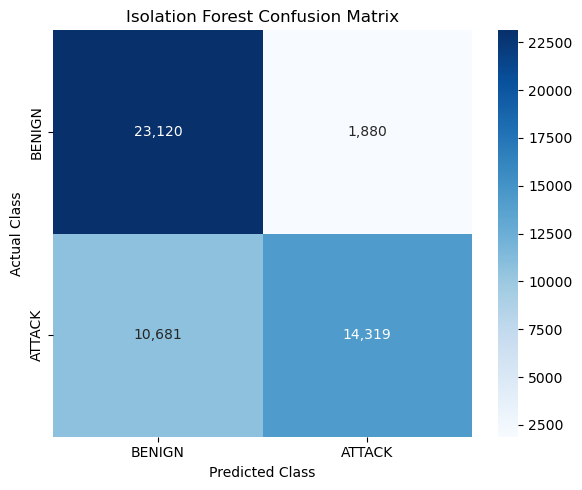

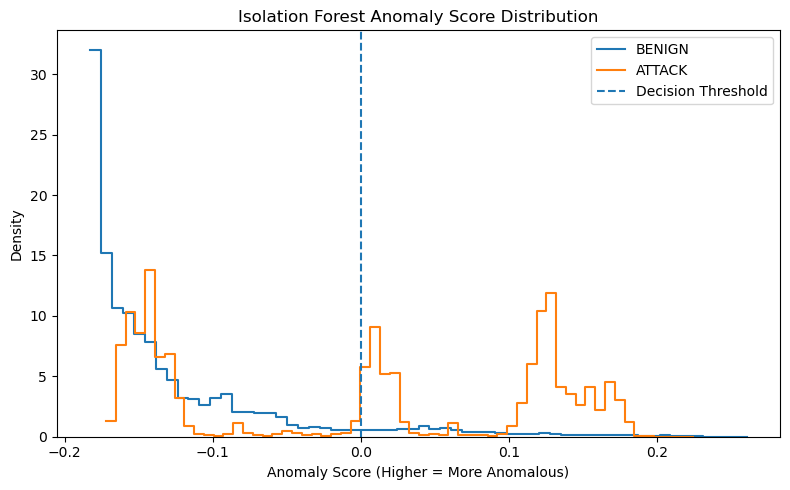

Isolation Forest Anomaly Score Summary
--------------------------------------
Mean BENIGN anomaly score: -0.1270
Mean ATTACK anomaly score: -0.0031
Median BENIGN anomaly score: -0.1537
Median ATTACK anomaly score: 0.0098


In [18]:
# ============================================================
# STEP 10: Visualising Isolation Forest Results
# ============================================================

# This step creates two figures:
#
# 1. Confusion matrix to show correct and incorrect classifications.
#
# 2. Anomaly-score distribution to show how well Isolation Forest separates benign and malicious network traffic based on anomaly scores.



# 1. Isolation Forest Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    isolation_cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["BENIGN", "ATTACK"],
    yticklabels=["BENIGN", "ATTACK"]
)

plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

# Saving the figure
plt.savefig(
    "isolation_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 2. Calculating anomaly scores

# decision_function() produces a score describing how normal
# each observation appears according to Isolation Forest.
#
# Higher values normally indicate more normal observations,
# while lower values indicate more anomalous observations.
#
# multiplying the scores by -1 so that HIGHER values represent
# stronger anomaly scores to make the graph easier to read.

isolation_anomaly_scores = -isolation_forest.decision_function(
    X_test_scaled
)


# 3. Separating scores using the TRUE test labels

benign_scores = isolation_anomaly_scores[y_test_sample == 0]
attack_scores = isolation_anomaly_scores[y_test_sample == 1]


# 4. Plotting anomaly-score distributions

plt.figure(figsize=(8, 5))

sns.histplot(
    benign_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="BENIGN"
)

sns.histplot(
    attack_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="ATTACK"
)

# Because we reversed the decision-function sign above, Isolation Forest's default decision boundary is 0.
plt.axvline(
    x=0,
    linestyle="--",
    label="Decision Threshold"
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Higher = More Anomalous)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    "isolation_forest_anomaly_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Displaying basic score statistics

print("Isolation Forest Anomaly Score Summary")
print("--------------------------------------")

print(
    f"Mean BENIGN anomaly score: "
    f"{benign_scores.mean():.4f}"
)

print(
    f"Mean ATTACK anomaly score: "
    f"{attack_scores.mean():.4f}"
)

print(
    f"Median BENIGN anomaly score: "
    f"{np.median(benign_scores):.4f}"
)

print(
    f"Median ATTACK anomaly score: "
    f"{np.median(attack_scores):.4f}"
)

In [20]:
# ============================================================
# STEP 11: Training and Evaluate One-Class SVM
# ============================================================

# One-Class SVM is a novelty-detection algorithm that learns
# a boundary around normal observations.
#
# In this project, the model learns this boundary using ONLY
# benign CICIDS2017 network traffic. It is then tested on
# previously unseen benign and attack traffic.



# 1. Creating the One-Class SVM model

one_class_svm = OneClassSVM(
    # RBF allows the model to learn a non-linear boundary around normal network behaviour.
    kernel="rbf",

    # 'scale' automatically calculates gamma based on the number and variance of the input features.
    gamma="scale",

    # nu controls the expected proportion of training points allowed outside the learned normal boundary.
    # 0.05 provides a reasonable initial setting for the benign-only training.
    nu=0.05
)


# 2. Training the model on BENIGN traffic only

print("Training One-Class SVM...")
print("This model may take longer than Isolation Forest.")

start_train = time.perf_counter()

one_class_svm.fit(X_train_scaled)

ocsvm_train_time = time.perf_counter() - start_train

print("Training complete.")



# 3. Predicting the unseen test traffic

print("\nPredicting test traffic...")

start_predict = time.perf_counter()

# One-Class SVM prediction convention:
#  1 = normal/inlier
# -1 = anomaly/outlier
ocsvm_raw_predictions = one_class_svm.predict(X_test_scaled)

ocsvm_prediction_time = time.perf_counter() - start_predict


# 4. Converting predictions to project labels

# Project convention:
# 0 = BENIGN / Normal
# 1 = ATTACK / Anomaly

ocsvm_predictions = np.where(
    ocsvm_raw_predictions == -1,
    1,
    0
)


# 5. Calculating evaluation metrics

ocsvm_accuracy = accuracy_score(
    y_test_sample,
    ocsvm_predictions
)

ocsvm_precision = precision_score(
    y_test_sample,
    ocsvm_predictions,
    zero_division=0
)

ocsvm_recall = recall_score(
    y_test_sample,
    ocsvm_predictions,
    zero_division=0
)

ocsvm_f1 = f1_score(
    y_test_sample,
    ocsvm_predictions,
    zero_division=0
)


# 6. Calculating confusion matrix

ocsvm_cm = confusion_matrix(
    y_test_sample,
    ocsvm_predictions,
    labels=[0, 1]
)

ocsvm_tn, ocsvm_fp, ocsvm_fn, ocsvm_tp = ocsvm_cm.ravel()


# 7. Calculating false-positive rate

ocsvm_fpr = ocsvm_fp / (ocsvm_fp + ocsvm_tn)


# 8. Displaying evaluation results

print("\nOne-Class SVM Results")
print("---------------------")

print(f"Accuracy:            {ocsvm_accuracy:.4f}")
print(f"Precision:           {ocsvm_precision:.4f}")
print(f"Recall:              {ocsvm_recall:.4f}")
print(f"F1-score:            {ocsvm_f1:.4f}")
print(f"False-positive rate: {ocsvm_fpr:.4f}")


print("\nConfusion Matrix Values")
print("-----------------------")

print(f"True Negatives  (TN): {ocsvm_tn:,}")
print(f"False Positives (FP): {ocsvm_fp:,}")
print(f"False Negatives  (FN): {ocsvm_fn:,}")
print(f"True Positives   (TP): {ocsvm_tp:,}")


print("\nExecution Time")
print("--------------")

print(f"Training time:   {ocsvm_train_time:.2f} seconds")
print(f"Prediction time: {ocsvm_prediction_time:.2f} seconds")


# 9. Displaying detailed classification report

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test_sample,
        ocsvm_predictions,
        target_names=["BENIGN", "ATTACK"],
        digits=4,
        zero_division=0
    )
)

Training One-Class SVM...
This model may take longer than Isolation Forest.
Training complete.

Predicting test traffic...

One-Class SVM Results
---------------------
Accuracy:            0.7703
Precision:           0.9203
Recall:              0.5918
F1-score:            0.7204
False-positive rate: 0.0512

Confusion Matrix Values
-----------------------
True Negatives  (TN): 23,719
False Positives (FP): 1,281
False Negatives  (FN): 10,204
True Positives   (TP): 14,796

Execution Time
--------------
Training time:   16.66 seconds
Prediction time: 11.50 seconds

Classification Report
---------------------
              precision    recall  f1-score   support

      BENIGN     0.6992    0.9488    0.8051     25000
      ATTACK     0.9203    0.5918    0.7204     25000

    accuracy                         0.7703     50000
   macro avg     0.8098    0.7703    0.7627     50000
weighted avg     0.8098    0.7703    0.7627     50000



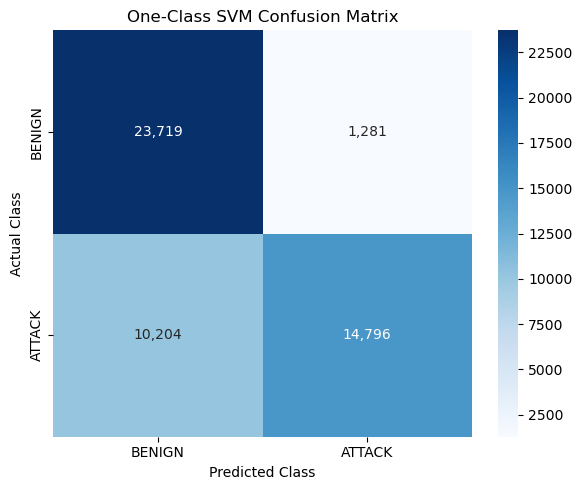

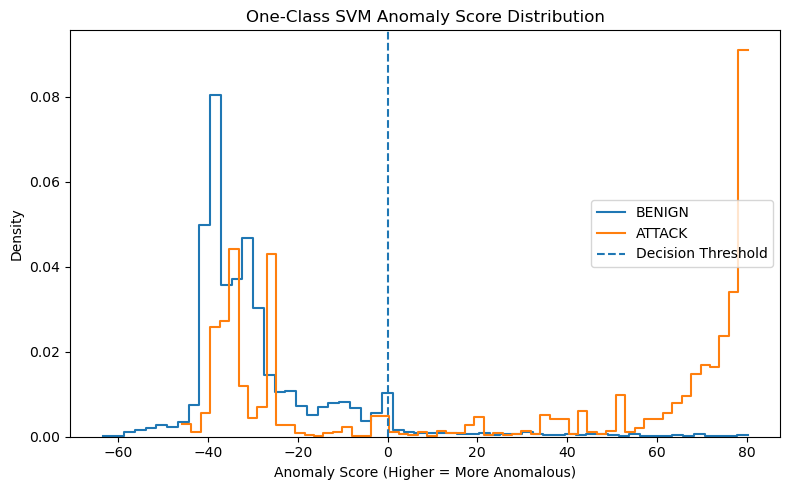

One-Class SVM Anomaly Score Summary
-----------------------------------
Mean BENIGN anomaly score: -28.4425
Mean ATTACK anomaly score: 27.3283
Median BENIGN anomaly score: -33.2952
Median ATTACK anomaly score: 52.1619


In [22]:
# ============================================================
# STEP 12: Visualising One-Class SVM Results
# ============================================================

# This creates:
#
# 1. A confusion matrix showing correct and incorrect One-Class SVM predictions.
#
# 2. An anomaly-score distribution showing how the model separates benign and malicious network traffic.


# 1. One-Class SVM Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    ocsvm_cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["BENIGN", "ATTACK"],
    yticklabels=["BENIGN", "ATTACK"]
)

plt.title("One-Class SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

# Saving the figure
plt.savefig(
    "one_class_svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 2. Calculating One-Class SVM anomaly scores

# decision_function() normally gives higher values to observations considered normal.

# Multiplying by -1 reverses the direction so that:
# Higher score = more anomalous
# Lower score  = more normal
# The model's default decision boundary remains at 0.

ocsvm_anomaly_scores = -one_class_svm.decision_function(
    X_test_scaled
)


# 3. Separating scores by the TRUE test labels

ocsvm_benign_scores = ocsvm_anomaly_scores[
    y_test_sample == 0
]

ocsvm_attack_scores = ocsvm_anomaly_scores[
    y_test_sample == 1
]


# 4. Plotting anomaly-score distributions

plt.figure(figsize=(8, 5))

sns.histplot(
    ocsvm_benign_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="BENIGN"
)

sns.histplot(
    ocsvm_attack_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="ATTACK"
)

# The One-Class SVM decision boundary is zero.
plt.axvline(
    x=0,
    linestyle="--",
    label="Decision Threshold"
)

plt.title("One-Class SVM Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Higher = More Anomalous)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    "one_class_svm_anomaly_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Displaying anomaly-score statistics

print("One-Class SVM Anomaly Score Summary")
print("-----------------------------------")

print(
    f"Mean BENIGN anomaly score: "
    f"{ocsvm_benign_scores.mean():.4f}"
)

print(
    f"Mean ATTACK anomaly score: "
    f"{ocsvm_attack_scores.mean():.4f}"
)

print(
    f"Median BENIGN anomaly score: "
    f"{np.median(ocsvm_benign_scores):.4f}"
)

print(
    f"Median ATTACK anomaly score: "
    f"{np.median(ocsvm_attack_scores):.4f}"
)

In [24]:
novelty=True

In [26]:
# ============================================================
# STEP 13: Training and Evaluating Local Outlier Factor (LOF)
# ============================================================

# Local Outlier Factor (LOF) identifies unusual observations by comparing the local density of each observation with the density of its neighbouring observations.
# novelty=True is important to learn normal behaviour from the BENIGN training data and then predict previously unseen network traffic.



# 1. Creating the LOF model

lof = LocalOutlierFactor(
    
    # Number of neighbouring observations used to estimate the local density around each network flow.
    n_neighbors=20,
    
    # novelty=True allows LOF to predict anomalies in NEW observations that were not part of the training data.
    novelty=True,
    
    # Automatically determine the default outlier threshold. Not using the attack labels to set this threshold.
    contamination="auto",
    
    # Using all available CPU cores where supported.
    n_jobs=-1
)


# 2. Training LOF using BENIGN traffic only

print("Training Local Outlier Factor...")
print("This may take longer because LOF performs neighbour searches.")

start_train = time.perf_counter()

lof.fit(X_train_scaled)

lof_train_time = time.perf_counter() - start_train

print("Training complete.")


# 3. Predicting unseen test traffic

print("\nPredicting test traffic...")

start_predict = time.perf_counter()

# LOF prediction convention:
#  1 = normal/inlier
# -1 = anomaly/outlier
lof_raw_predictions = lof.predict(X_test_scaled)

lof_prediction_time = time.perf_counter() - start_predict


# 4. Converting predictions to project labels

# Convention:
# 0 = BENIGN / Normal
# 1 = ATTACK / Anomaly

lof_predictions = np.where(
    lof_raw_predictions == -1,
    1,
    0
)


# 5. Calculating evaluation metrics

lof_accuracy = accuracy_score(
    y_test_sample,
    lof_predictions
)

lof_precision = precision_score(
    y_test_sample,
    lof_predictions,
    zero_division=0
)

lof_recall = recall_score(
    y_test_sample,
    lof_predictions,
    zero_division=0
)

lof_f1 = f1_score(
    y_test_sample,
    lof_predictions,
    zero_division=0
)


# 6. Calculate confusion matrix

lof_cm = confusion_matrix(
    y_test_sample,
    lof_predictions,
    labels=[0, 1]
)

lof_tn, lof_fp, lof_fn, lof_tp = lof_cm.ravel()


# 7. Calculating false-positive rate

lof_fpr = lof_fp / (lof_fp + lof_tn)


# 8. Displaying evaluation results


print("\nLocal Outlier Factor Results")
print("----------------------------")

print(f"Accuracy:            {lof_accuracy:.4f}")
print(f"Precision:           {lof_precision:.4f}")
print(f"Recall:              {lof_recall:.4f}")
print(f"F1-score:            {lof_f1:.4f}")
print(f"False-positive rate: {lof_fpr:.4f}")


print("\nConfusion Matrix Values")
print("-----------------------")

print(f"True Negatives  (TN): {lof_tn:,}")
print(f"False Positives (FP): {lof_fp:,}")
print(f"False Negatives  (FN): {lof_fn:,}")
print(f"True Positives   (TP): {lof_tp:,}")


print("\nExecution Time")
print("--------------")

print(f"Training time:   {lof_train_time:.2f} seconds")
print(f"Prediction time: {lof_prediction_time:.2f} seconds")


# 9. Displaying detailed classification report

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test_sample,
        lof_predictions,
        target_names=["BENIGN", "ATTACK"],
        digits=4,
        zero_division=0
    )
)

Training Local Outlier Factor...
This may take longer because LOF performs neighbour searches.
Training complete.

Predicting test traffic...

Local Outlier Factor Results
----------------------------
Accuracy:            0.8554
Precision:           0.8579
Recall:              0.8520
F1-score:            0.8549
False-positive rate: 0.1411

Confusion Matrix Values
-----------------------
True Negatives  (TN): 21,472
False Positives (FP): 3,528
False Negatives  (FN): 3,701
True Positives   (TP): 21,299

Execution Time
--------------
Training time:   2.76 seconds
Prediction time: 2.78 seconds

Classification Report
---------------------
              precision    recall  f1-score   support

      BENIGN     0.8530    0.8589    0.8559     25000
      ATTACK     0.8579    0.8520    0.8549     25000

    accuracy                         0.8554     50000
   macro avg     0.8554    0.8554    0.8554     50000
weighted avg     0.8554    0.8554    0.8554     50000



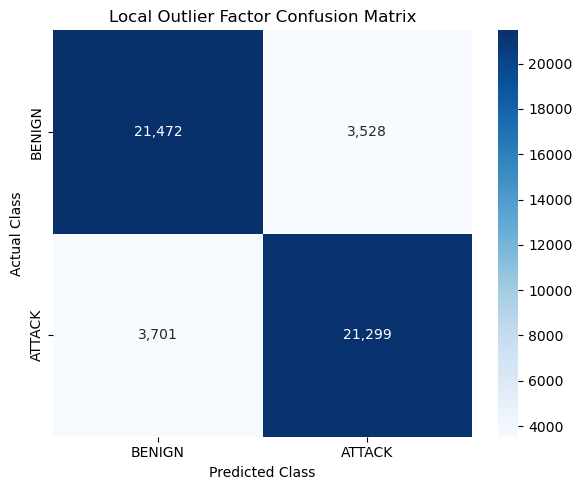

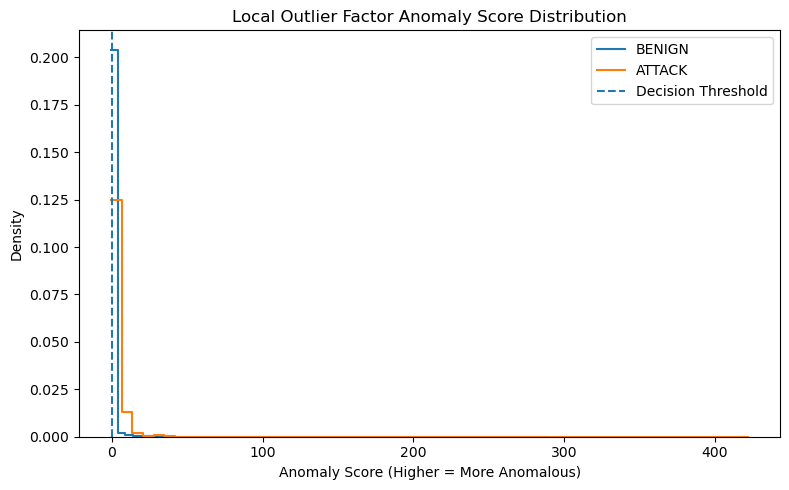

LOF Anomaly Score Summary
-------------------------
Mean BENIGN anomaly score: 0.1923
Mean ATTACK anomaly score: 2.9026
Median BENIGN anomaly score: -0.4362
Median ATTACK anomaly score: 1.3502


In [28]:
# ============================================================
# STEP 14: Visualising Local Outlier Factor (LOF) Results
# ============================================================

# This creates:
#
# 1. A confusion matrix for LOF.
# 2. An anomaly-score distribution showing the separation between benign and malicious network traffic.



# 1. LOF Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    lof_cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["BENIGN", "ATTACK"],
    yticklabels=["BENIGN", "ATTACK"]
)

plt.title("Local Outlier Factor Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

# Saving the confusion matrix
plt.savefig(
    "lof_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 2. Calculating LOF anomaly scores

# decision_function() normally produces higher values for observations considered normal.
#
# We multiply the values by -1 so that:
#
# Higher score = more anomalous
# Lower score  = more normal

lof_anomaly_scores = -lof.decision_function(
    X_test_scaled
)

# 3. Separating scores using the TRUE test labels

lof_benign_scores = lof_anomaly_scores[
    y_test_sample == 0
]

lof_attack_scores = lof_anomaly_scores[
    y_test_sample == 1
]


# 4. Plotting anomaly-score distributions

plt.figure(figsize=(8, 5))

sns.histplot(
    lof_benign_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="BENIGN"
)

sns.histplot(
    lof_attack_scores,
    bins=60,
    stat="density",
    element="step",
    fill=False,
    label="ATTACK"
)

# LOF's decision boundary for novelty detection is zero.
plt.axvline(
    x=0,
    linestyle="--",
    label="Decision Threshold"
)

plt.title("Local Outlier Factor Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Higher = More Anomalous)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    "lof_anomaly_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Displaying anomaly-score statistics

print("LOF Anomaly Score Summary")
print("-------------------------")

print(
    f"Mean BENIGN anomaly score: "
    f"{lof_benign_scores.mean():.4f}"
)

print(
    f"Mean ATTACK anomaly score: "
    f"{lof_attack_scores.mean():.4f}"
)

print(
    f"Median BENIGN anomaly score: "
    f"{np.median(lof_benign_scores):.4f}"
)

print(
    f"Median ATTACK anomaly score: "
    f"{np.median(lof_attack_scores):.4f}"
)

Final Model Comparison
----------------------


,Model,Accuracy,Precision,Recall,F1-score,False Positive Rate,Training Time (s),Prediction Time (s)
0,Isolation Forest,0.7488,0.8839,0.5728,0.6951,0.0752,0.37,0.21
1,One-Class SVM,0.7703,0.9203,0.5918,0.7204,0.0512,16.66,11.50
2,Local Outlier Factor,0.8554,0.8579,0.8520,0.8549,0.1411,2.76,2.78



Results saved as: anomaly_detection_model_results.csv


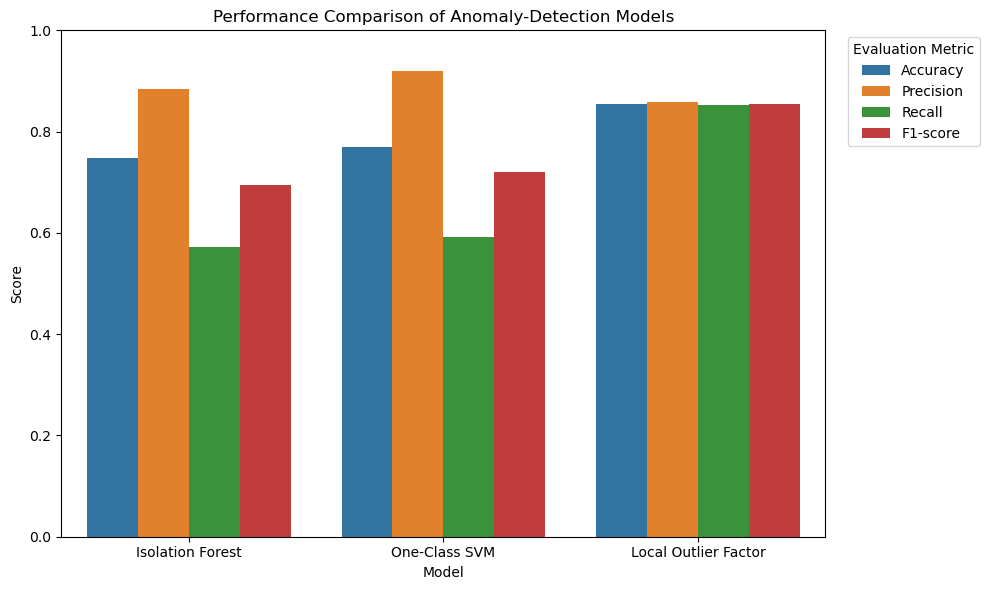

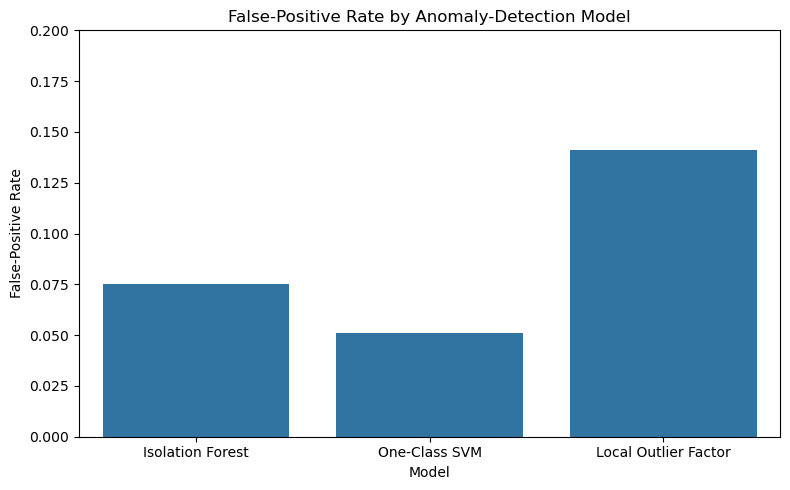

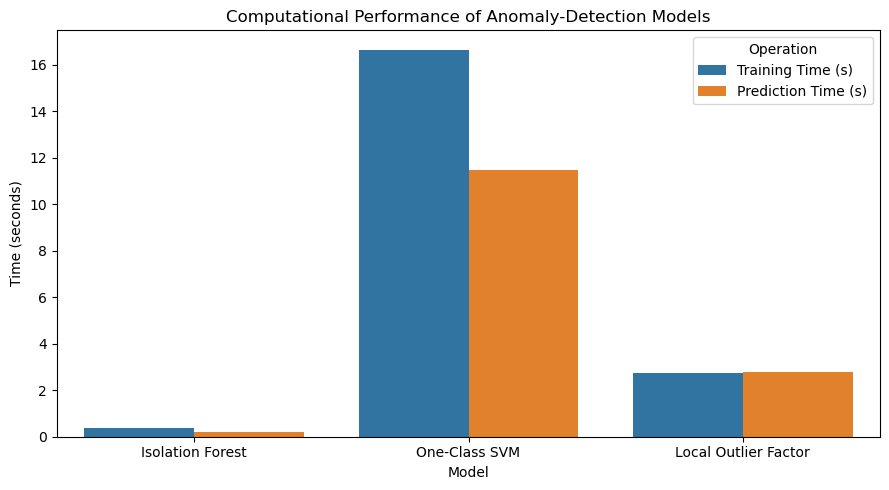

In [30]:
# ============================================================
# STEP 15: Comparing All Three Anomaly-Detection Models
# ============================================================

# This step combines the actual results produced by:
#
# 1. Isolation Forest
# 2. One-Class SVM
# 3. Local Outlier Factor
#
# No performance values are manually entered. This prevents accidental differences between the notebook results and the values reported in the final research paper.


# 1. Creating the model comparison table

model_results = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "One-Class SVM",
        "Local Outlier Factor"
    ],

    "Accuracy": [
        isolation_accuracy,
        ocsvm_accuracy,
        lof_accuracy
    ],

    "Precision": [
        isolation_precision,
        ocsvm_precision,
        lof_precision
    ],

    "Recall": [
        isolation_recall,
        ocsvm_recall,
        lof_recall
    ],

    "F1-score": [
        isolation_f1,
        ocsvm_f1,
        lof_f1
    ],

    "False Positive Rate": [
        isolation_fpr,
        ocsvm_fpr,
        lof_fpr
    ],

    "Training Time (s)": [
        isolation_train_time,
        ocsvm_train_time,
        lof_train_time
    ],

    "Prediction Time (s)": [
        isolation_prediction_time,
        ocsvm_prediction_time,
        lof_prediction_time
    ]
})


# 2. Displaying the comparison table

print("Final Model Comparison")
print("----------------------")

display(
    model_results.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "False Positive Rate": 4,
        "Training Time (s)": 2,
        "Prediction Time (s)": 2
    })
)


# 3. Saving the results to CSV

model_results.to_csv(
    "anomaly_detection_model_results.csv",
    index=False
)

print(
    "\nResults saved as: "
    "anomaly_detection_model_results.csv"
)



# 4. Creating a detection-performance comparison graph

# Converting the table into long format so multiple evaluation metrics can be displayed for each model.

performance_plot = model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=performance_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Performance Comparison of Anomaly-Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Comparing false-positive rates

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="False Positive Rate"
)

plt.title(
    "False-Positive Rate by Anomaly-Detection Model"
)

plt.xlabel("Model")
plt.ylabel("False-Positive Rate")

plt.ylim(0, 0.20)

plt.tight_layout()

plt.savefig(
    "false_positive_rate_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 6. Comparing computational performance

time_results = model_results[
    [
        "Model",
        "Training Time (s)",
        "Prediction Time (s)"
    ]
].melt(
    id_vars="Model",
    var_name="Operation",
    value_name="Time (seconds)"
)


plt.figure(figsize=(9, 5))

sns.barplot(
    data=time_results,
    x="Model",
    y="Time (seconds)",
    hue="Operation"
)

plt.title(
    "Computational Performance of Anomaly-Detection Models"
)

plt.xlabel("Model")
plt.ylabel("Time (seconds)")

plt.legend(title="Operation")

plt.tight_layout()

plt.savefig(
    "model_execution_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC-AUC Results
---------------
Isolation Forest ROC-AUC: 0.8063
One-Class SVM ROC-AUC:    0.8059
Local Outlier Factor ROC-AUC: 0.8970


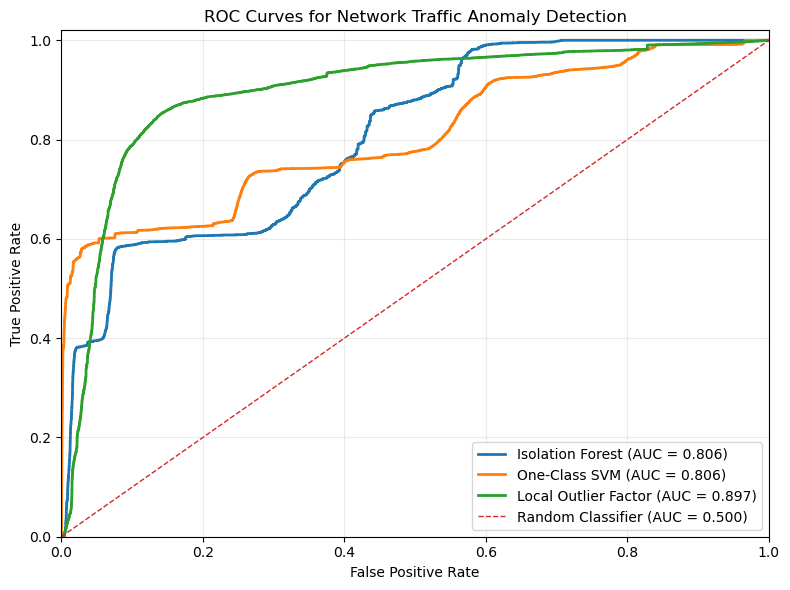


Updated Model Comparison
------------------------


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,False Positive Rate,Training Time (s),Prediction Time (s)
0,Isolation Forest,0.7488,0.8839,0.5728,0.6951,0.8063,0.0752,0.37,0.21
1,One-Class SVM,0.7703,0.9203,0.5918,0.7204,0.8059,0.0512,16.66,11.50
2,Local Outlier Factor,0.8554,0.8579,0.8520,0.8549,0.8970,0.1411,2.76,2.78



Updated results saved to: anomaly_detection_model_results.csv


In [32]:
# ============================================================
# STEP 16: ROC Curves and ROC-AUC Comparison
# ============================================================

# ROC analysis evaluates how well each model separates BENIGN and ATTACK traffic across many possible decision thresholds.

# Unlike accuracy, precision, recall and F1-score, ROC-AUC does not depend on only the model's default threshold.

# Ground truth:
# 0 = BENIGN
# 1 = ATTACK

# Anomaly scores:
# Higher value = more anomalous


# 1. Calculating ROC-AUC for each model

isolation_auc = roc_auc_score(
    y_test_sample,
    isolation_anomaly_scores
)

ocsvm_auc = roc_auc_score(
    y_test_sample,
    ocsvm_anomaly_scores
)

lof_auc = roc_auc_score(
    y_test_sample,
    lof_anomaly_scores
)


# 2. Displaying ROC-AUC values

print("ROC-AUC Results")
print("---------------")

print(
    f"Isolation Forest ROC-AUC: "
    f"{isolation_auc:.4f}"
)

print(
    f"One-Class SVM ROC-AUC:    "
    f"{ocsvm_auc:.4f}"
)

print(
    f"Local Outlier Factor ROC-AUC: "
    f"{lof_auc:.4f}"
)


# 3. Calculating ROC curve coordinates

fpr_isolation, tpr_isolation, _ = roc_curve(
    y_test_sample,
    isolation_anomaly_scores
)

fpr_ocsvm, tpr_ocsvm, _ = roc_curve(
    y_test_sample,
    ocsvm_anomaly_scores
)

fpr_lof, tpr_lof, _ = roc_curve(
    y_test_sample,
    lof_anomaly_scores
)


# 4. Plotting all three ROC curves

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_isolation,
    tpr_isolation,
    linewidth=2,
    label=f"Isolation Forest (AUC = {isolation_auc:.3f})"
)

plt.plot(
    fpr_ocsvm,
    tpr_ocsvm,
    linewidth=2,
    label=f"One-Class SVM (AUC = {ocsvm_auc:.3f})"
)

plt.plot(
    fpr_lof,
    tpr_lof,
    linewidth=2,
    label=f"Local Outlier Factor (AUC = {lof_auc:.3f})"
)


# 5. Adding random-classifier reference line

# A completely random detector would have an AUC of approximately 0.50.

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier (AUC = 0.500)"
)


# 6. Formatting and saving the graph

plt.title(
    "ROC Curves for Network Traffic Anomaly Detection"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.legend(loc="lower right")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "roc_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. Adding ROC-AUC values to the main results table

auc_mapping = {
    "Isolation Forest": isolation_auc,
    "One-Class SVM": ocsvm_auc,
    "Local Outlier Factor": lof_auc
}

model_results["ROC-AUC"] = (
    model_results["Model"].map(auc_mapping)
)


# Reordering the columns so ROC-AUC appears with the other detection-performance metrics.

model_results = model_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "False Positive Rate",
        "Training Time (s)",
        "Prediction Time (s)"
    ]
]


# 8. Displaying the updated results table

print("\nUpdated Model Comparison")
print("------------------------")

display(
    model_results.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "ROC-AUC": 4,
        "False Positive Rate": 4,
        "Training Time (s)": 2,
        "Prediction Time (s)": 2
    })
)


# 9. Updating the saved CSV

model_results.to_csv(
    "anomaly_detection_model_results.csv",
    index=False
)

print(
    "\nUpdated results saved to: "
    "anomaly_detection_model_results.csv"
)

Per-Attack Evaluation
---------------------
Total attack flows to evaluate: 425,741
Number of attack categories: 14

Evaluating attack traffic in batches...
Processed 10,000 / 425,741 attack flows
Processed 20,000 / 425,741 attack flows
Processed 30,000 / 425,741 attack flows
Processed 40,000 / 425,741 attack flows
Processed 50,000 / 425,741 attack flows
Processed 60,000 / 425,741 attack flows
Processed 70,000 / 425,741 attack flows
Processed 80,000 / 425,741 attack flows
Processed 90,000 / 425,741 attack flows
Processed 100,000 / 425,741 attack flows
Processed 110,000 / 425,741 attack flows
Processed 120,000 / 425,741 attack flows
Processed 130,000 / 425,741 attack flows
Processed 140,000 / 425,741 attack flows
Processed 150,000 / 425,741 attack flows
Processed 160,000 / 425,741 attack flows
Processed 170,000 / 425,741 attack flows
Processed 180,000 / 425,741 attack flows
Processed 190,000 / 425,741 attack flows
Processed 200,000 / 425,741 attack flows
Processed 210,000 / 425,741 atta

,Attack Type,Samples,Isolation_Forest,One_Class_SVM,Local_Outlier_Factor
0,DoS Hulk,172846,0.8853,0.8996,0.9339
1,DDoS,128014,0.6173,0.6358,0.9595
2,PortScan,90694,0.0028,0.0154,0.6661
3,DoS GoldenEye,10286,0.5813,0.7288,0.6804
4,FTP-Patator,5931,0.0000,0.0010,0.3802
5,DoS slowloris,5385,0.5902,0.6156,0.7044
6,DoS Slowhttptest,5228,0.8015,0.9155,0.2362
7,SSH-Patator,3219,0.0000,0.0009,0.9919
8,Bot,1948,0.0226,0.0339,0.0287
9,Web Attack - Brute Force,1470,0.0497,0.0503,0.1293



Results saved as: detection_rate_by_attack_type.csv


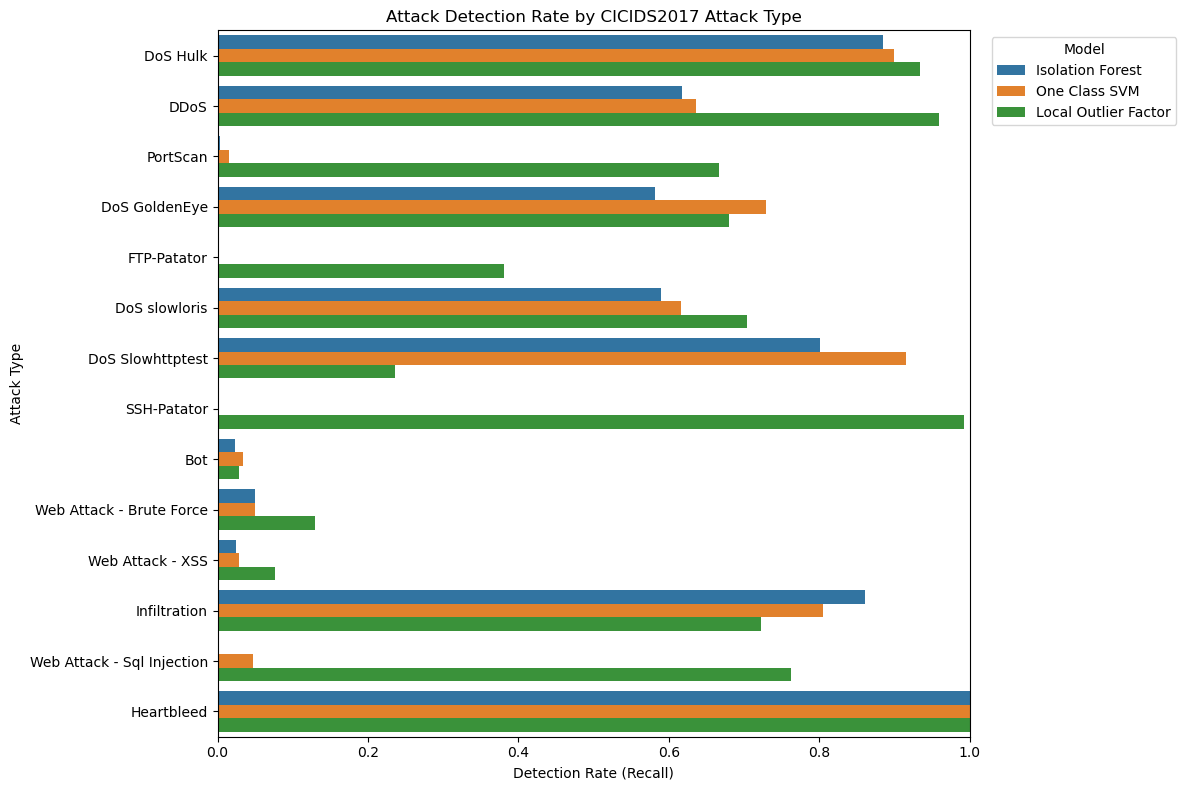

In [34]:
# ============================================================
# STEP 17: Evaluating Detection Rate by Attack Type
# ============================================================

# The balanced 50,000-flow test set was appropriate for the overall comparison of the three models.
#
# However, CICIDS2017 attack categories are highly imbalanced.
# A random 25,000-attack sample contained very few examples of
# rare attacks such as Heartbleed and SQL Injection.
#
# Therefore, this analysis evaluates ALL cleaned attack flows.
# None of these attack flows were used to train the models.


# 1. Preparing all attack traffic

X_all_attacks = X_attack_reduced.copy()

all_attack_labels = df.loc[
    X_all_attacks.index,
    "Label"
].copy()

print("Per-Attack Evaluation")
print("---------------------")
print(f"Total attack flows to evaluate: {len(X_all_attacks):,}")
print(f"Number of attack categories: {all_attack_labels.nunique()}")


# 2. Processing attack traffic in batches

# Processing in batches reduces peak memory usage and is safer for algorithms such as One-Class SVM and LOF.

BATCH_SIZE = 10000

isolation_attack_predictions = []
ocsvm_attack_predictions = []
lof_attack_predictions = []


print("\nEvaluating attack traffic in batches...")


for start in range(0, len(X_all_attacks), BATCH_SIZE):

    end = min(
        start + BATCH_SIZE,
        len(X_all_attacks)
    )

    # Selecting the current batch.
    X_batch = X_all_attacks.iloc[start:end]

    # Applying the SAME scaler fitted previously using only the benign training data.
    X_batch_scaled = scaler.transform(X_batch)


   
    # Isolation Forest predictions

    isolation_batch_raw = isolation_forest.predict(
        X_batch_scaled
    )

    isolation_batch = np.where(
        isolation_batch_raw == -1,
        1,
        0
    )

    isolation_attack_predictions.extend(
        isolation_batch
    )


    # One-Class SVM predictions

    ocsvm_batch_raw = one_class_svm.predict(
        X_batch_scaled
    )

    ocsvm_batch = np.where(
        ocsvm_batch_raw == -1,
        1,
        0
    )

    ocsvm_attack_predictions.extend(
        ocsvm_batch
    )


    # Local Outlier Factor predictions

    lof_batch_raw = lof.predict(
        X_batch_scaled
    )

    lof_batch = np.where(
        lof_batch_raw == -1,
        1,
        0
    )

    lof_attack_predictions.extend(
        lof_batch
    )


    print(
        f"Processed {end:,} / "
        f"{len(X_all_attacks):,} attack flows"
    )



# 3. Creating a detailed attack-results DataFrame

attack_evaluation = pd.DataFrame({
    "Attack Type": all_attack_labels.values,

    "Isolation Forest": np.array(
        isolation_attack_predictions
    ),

    "One-Class SVM": np.array(
        ocsvm_attack_predictions
    ),

    "Local Outlier Factor": np.array(
        lof_attack_predictions
    )
})


# 4. Calculating detection rate for each attack category

# Since every row in this DataFrame is a real attack:
# prediction = 1 -> correctly detected attack
# prediction = 0 -> missed attack
# Therefore, the mean of the predictions gives the detection rate (recall) for that attack category.

attack_detection_rates = (
    attack_evaluation
    .groupby("Attack Type")
    .agg(
        Samples=("Attack Type", "size"),

        Isolation_Forest=(
            "Isolation Forest",
            "mean"
        ),

        One_Class_SVM=(
            "One-Class SVM",
            "mean"
        ),

        Local_Outlier_Factor=(
            "Local Outlier Factor",
            "mean"
        )
    )
    .reset_index()
)


# 5. Sorting categories by number of available samples

attack_detection_rates = (
    attack_detection_rates
    .sort_values(
        "Samples",
        ascending=False
    )
    .reset_index(drop=True)
)


# 6. Displaying the complete table

print("\nDetection Rate by Attack Type")
print("-----------------------------")

display(
    attack_detection_rates.round({
        "Isolation_Forest": 4,
        "One_Class_SVM": 4,
        "Local_Outlier_Factor": 4
    })
)


# 7. Saving detailed results to CSV

attack_detection_rates.to_csv(
    "detection_rate_by_attack_type.csv",
    index=False
)

print(
    "\nResults saved as: "
    "detection_rate_by_attack_type.csv"
)


# 8. Creating a grouped bar chart

attack_plot_data = attack_detection_rates.melt(
    id_vars=[
        "Attack Type",
        "Samples"
    ],

    value_vars=[
        "Isolation_Forest",
        "One_Class_SVM",
        "Local_Outlier_Factor"
    ],

    var_name="Model",
    value_name="Detection Rate"
)


# Making model names easier to read on the graph.
attack_plot_data["Model"] = (
    attack_plot_data["Model"]
    .str.replace("_", " ", regex=False)
)


plt.figure(figsize=(12, 8))

sns.barplot(
    data=attack_plot_data,
    y="Attack Type",
    x="Detection Rate",
    hue="Model"
)

plt.title(
    "Attack Detection Rate by CICIDS2017 Attack Type"
)

plt.xlabel("Detection Rate (Recall)")
plt.ylabel("Attack Type")

plt.xlim(0, 1)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "detection_rate_by_attack_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# ============================================================
# STEP 18: Analysing Model Performance by Attack Category
# ============================================================

# This step analyses the per-attack detection rates calculated in Step 17.
#
# The purpose is to identify:
# 1. Which model performs best for each attack type
# 2. Which attacks are difficult for all three models
# 3. Which attacks are detected reliably
# 4. How many attack categories each model performs best on


# 1. Creating a cleaner copy of the Step 17 results

attack_summary = attack_detection_rates.copy()

model_columns = [
    "Isolation_Forest",
    "One_Class_SVM",
    "Local_Outlier_Factor"
]


# 2. Finding the best model for each attack category

attack_summary["Best Model"] = (
    attack_summary[model_columns]
    .idxmax(axis=1)
    .str.replace("_", " ", regex=False)
)

attack_summary["Best Detection Rate"] = (
    attack_summary[model_columns]
    .max(axis=1)
)


# 3. Calculating the average detection rate across the 3 models

# This is an unweighted macro average across models for each attack type. It helps identify attacks that are generally difficult for anomaly detection.

attack_summary["Average Detection Rate"] = (
    attack_summary[model_columns].mean(axis=1)
)


# 4. Classifing the general difficulty of each attack

# These categories are descriptive only.
#
# High:     average detection >= 80%
# Moderate: average detection >= 50%
# Low:      average detection < 50%

attack_summary["Detection Level"] = np.select(
    [
        attack_summary["Average Detection Rate"] >= 0.80,
        attack_summary["Average Detection Rate"] >= 0.50
    ],
    [
        "High",
        "Moderate"
    ],
    default="Low"
)


# 5. Displaying the complete analysis

print("Attack-Type Performance Analysis")
print("--------------------------------")

display(
    attack_summary[
        [
            "Attack Type",
            "Samples",
            "Isolation_Forest",
            "One_Class_SVM",
            "Local_Outlier_Factor",
            "Best Model",
            "Best Detection Rate",
            "Average Detection Rate",
            "Detection Level"
        ]
    ].round({
        "Isolation_Forest": 4,
        "One_Class_SVM": 4,
        "Local_Outlier_Factor": 4,
        "Best Detection Rate": 4,
        "Average Detection Rate": 4
    })
)


# 6. Counting how many attack categories each model wins

best_model_counts = (
    attack_summary["Best Model"]
    .value_counts()
)

print("\nBest Model by Number of Attack Categories")
print("-----------------------------------------")
print(best_model_counts)


# 7. Identifying difficult attacks

# An attack is considered difficult here when even the BEST model detects fewer than 50% of its flows.

difficult_attacks = attack_summary[
    attack_summary["Best Detection Rate"] < 0.50
][
    [
        "Attack Type",
        "Samples",
        "Best Model",
        "Best Detection Rate"
    ]
]

print("\nAttack Types With Less Than 50% Detection")
print("-----------------------------------------")

if len(difficult_attacks) > 0:
    display(
        difficult_attacks.round({
            "Best Detection Rate": 4
        })
    )
else:
    print("None")


# 8. Identifying strongly detected attacks

# These are attacks where the best-performing model detects at least 90% of the available attack flows.

strong_attacks = attack_summary[
    attack_summary["Best Detection Rate"] >= 0.90
][
    [
        "Attack Type",
        "Samples",
        "Best Model",
        "Best Detection Rate"
    ]
]

print("\nAttack Types With At Least 90% Detection")
print("----------------------------------------")

display(
    strong_attacks.round({
        "Best Detection Rate": 4
    })
)


# 9. Saving the analysis

attack_summary.to_csv(
    "attack_type_performance_summary.csv",
    index=False
)

print(
    "\nAnalysis saved as: "
    "attack_type_performance_summary.csv"
)

Attack-Type Performance Analysis
--------------------------------


,Attack Type,Samples,Isolation_Forest,One_Class_SVM,Local_Outlier_Factor,Best Model,Best Detection Rate,Average Detection Rate,Detection Level
0,DoS Hulk,172846,0.8853,0.8996,0.9339,Local Outlier Factor,0.9339,0.9063,High
1,DDoS,128014,0.6173,0.6358,0.9595,Local Outlier Factor,0.9595,0.7375,Moderate
2,PortScan,90694,0.0028,0.0154,0.6661,Local Outlier Factor,0.6661,0.2281,Low
3,DoS GoldenEye,10286,0.5813,0.7288,0.6804,One Class SVM,0.7288,0.6635,Moderate
4,FTP-Patator,5931,0.0000,0.0010,0.3802,Local Outlier Factor,0.3802,0.1271,Low
5,DoS slowloris,5385,0.5902,0.6156,0.7044,Local Outlier Factor,0.7044,0.6367,Moderate
6,DoS Slowhttptest,5228,0.8015,0.9155,0.2362,One Class SVM,0.9155,0.6510,Moderate
7,SSH-Patator,3219,0.0000,0.0009,0.9919,Local Outlier Factor,0.9919,0.3310,Low
8,Bot,1948,0.0226,0.0339,0.0287,One Class SVM,0.0339,0.0284,Low
9,Web Attack - Brute Force,1470,0.0497,0.0503,0.1293,Local Outlier Factor,0.1293,0.0764,Low



Best Model by Number of Attack Categories
-----------------------------------------
Best Model
Local Outlier Factor    9
One Class SVM           3
Isolation Forest        2
Name: count, dtype: int64

Attack Types With Less Than 50% Detection
-----------------------------------------


,Attack Type,Samples,Best Model,Best Detection Rate
4,FTP-Patator,5931,Local Outlier Factor,0.3802
8,Bot,1948,One Class SVM,0.0339
9,Web Attack - Brute Force,1470,Local Outlier Factor,0.1293
10,Web Attack - XSS,652,Local Outlier Factor,0.0767



Attack Types With At Least 90% Detection
----------------------------------------


,Attack Type,Samples,Best Model,Best Detection Rate
0,DoS Hulk,172846,Local Outlier Factor,0.9339
1,DDoS,128014,Local Outlier Factor,0.9595
6,DoS Slowhttptest,5228,One Class SVM,0.9155
7,SSH-Patator,3219,Local Outlier Factor,0.9919
13,Heartbleed,11,Isolation Forest,1.0000



Analysis saved as: attack_type_performance_summary.csv


Expected Precision at Different Attack Prevalence Levels
---------------------------------------------------------


,1% attacks,5% attacks,10% attacks,25% attacks,50% attacks
Model,,,,,
Isolation Forest,0.0714,0.2862,0.4584,0.7174,0.8839
Local Outlier Factor,0.0575,0.2411,0.4015,0.6680,0.8579
One-Class SVM,0.1045,0.3781,0.5621,0.7938,0.9203


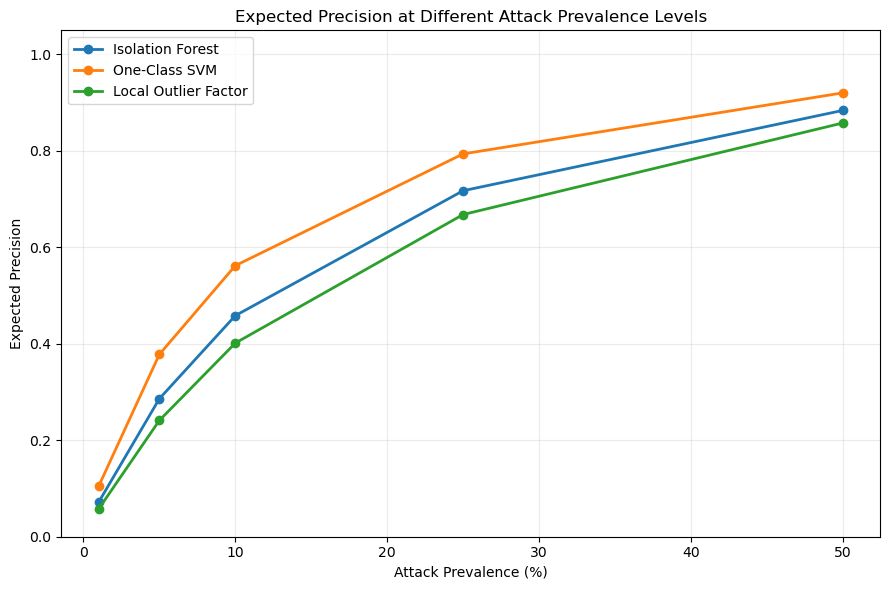


Expected Alerts per 100,000 Flows When Attack Prevalence = 1%
--------------------------------------------------------


,Model,True Attack Alerts,False Alerts,Total Alerts
0,Isolation Forest,573,7445,8018
1,One-Class SVM,592,5073,5665
2,Local Outlier Factor,852,13971,14823



Results saved as:
- attack_prevalence_analysis.csv
- expected_alerts_1_percent_attacks.csv


In [38]:
# ============================================================
# STEP 19: Evaluating Performance Under Different Attack Rates
# ============================================================

# Our main experimental test set was intentionally balanced:
# 50% BENIGN and 50% ATTACK.

# This makes model comparison easier, but real networks would normally contain a much smaller proportion of malicious traffic.

# This step estimates how precision changes when attacks make
# up 1%, 5%, 10%, 25%, and 50% of network traffic.


# No models are retrained here.
# Using the recall (TPR) and false-positive rate (FPR) already measured on the held-out test set.


# 1. Storing each model's measured TPR and FPR

deployment_metrics = {
    "Isolation Forest": {
        "TPR": isolation_recall,
        "FPR": isolation_fpr
    },

    "One-Class SVM": {
        "TPR": ocsvm_recall,
        "FPR": ocsvm_fpr
    },

    "Local Outlier Factor": {
        "TPR": lof_recall,
        "FPR": lof_fpr
    }
}


# 2. Defining hypothetical attack prevalence levels

# Example: 0.01 means that 1% of all network flows are attacks.

prevalence_levels = [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50
]


# 3. Calculating expected precision

# This demonstrates why false positives become especially important when actual attacks are rare.

prevalence_results = []

for model_name, metrics in deployment_metrics.items():

    tpr = metrics["TPR"]
    fpr = metrics["FPR"]

    for prevalence in prevalence_levels:

        expected_precision = (
            (tpr * prevalence)
            /
            (
                (tpr * prevalence)
                +
                (fpr * (1 - prevalence))
            )
        )

        prevalence_results.append({
            "Model": model_name,
            "Attack Prevalence": prevalence,
            "Expected Precision": expected_precision,
            "Recall": tpr,
            "False Positive Rate": fpr
        })


# 4. Converting results into a DataFrame

prevalence_df = pd.DataFrame(
    prevalence_results
)


# 5. Displaying a clean table

prevalence_table = prevalence_df.pivot(
    index="Model",
    columns="Attack Prevalence",
    values="Expected Precision"
)

# Converting prevalence values to percentages for readability.
prevalence_table.columns = [
    f"{int(value * 100)}% attacks"
    for value in prevalence_table.columns
]

print("Expected Precision at Different Attack Prevalence Levels")
print("---------------------------------------------------------")

display(
    prevalence_table.round(4)
)


# 6. Plotting expected precision

plt.figure(figsize=(9, 6))

for model_name in prevalence_df["Model"].unique():

    model_data = prevalence_df[
        prevalence_df["Model"] == model_name
    ]

    plt.plot(
        model_data["Attack Prevalence"] * 100,
        model_data["Expected Precision"],
        marker="o",
        linewidth=2,
        label=model_name
    )


plt.title(
    "Expected Precision at Different Attack Prevalence Levels"
)

plt.xlabel("Attack Prevalence (%)")
plt.ylabel("Expected Precision")

plt.ylim(0, 1.05)

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "precision_vs_attack_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. Calculating expected alerts per 100,000 network flows

# This provides a more practical interpretation of the false-positive problem.
# Using a scenario where 1% of traffic is malicious.

TOTAL_FLOWS = 100000
ATTACK_PREVALENCE = 0.01

attack_flows = int(
    TOTAL_FLOWS * ATTACK_PREVALENCE
)

benign_flows = (
    TOTAL_FLOWS - attack_flows
)

alert_results = []

for model_name, metrics in deployment_metrics.items():

    tpr = metrics["TPR"]
    fpr = metrics["FPR"]

    expected_true_alerts = (
        attack_flows * tpr
    )

    expected_false_alerts = (
        benign_flows * fpr
    )

    expected_total_alerts = (
        expected_true_alerts
        + expected_false_alerts
    )

    alert_results.append({
        "Model": model_name,
        "True Attack Alerts": round(
            expected_true_alerts
        ),
        "False Alerts": round(
            expected_false_alerts
        ),
        "Total Alerts": round(
            expected_total_alerts
        )
    })


alert_df = pd.DataFrame(
    alert_results
)


print(
    "\nExpected Alerts per 100,000 Flows "
    "When Attack Prevalence = 1%"
)

print(
    "--------------------------------------------------------"
)

display(alert_df)


# 8. Saving results

prevalence_df.to_csv(
    "attack_prevalence_analysis.csv",
    index=False
)

alert_df.to_csv(
    "expected_alerts_1_percent_attacks.csv",
    index=False
)

print(
    "\nResults saved as:"
)

print(
    "- attack_prevalence_analysis.csv"
)

print(
    "- expected_alerts_1_percent_attacks.csv"
)

In [40]:
# ============================================================
# STEP 20: Final Experimental Summary and Validation
# ============================================================

# This is the final experimental step.
# It does NOT train another model.
# it:
# 1. Summarises the experimental design
# 2. Reports the final performance of all three models
# 3. Identifies key strengths of each model
# 4. Checks the results for consistency
# 5. Saves a final summary 


# 1. Displaying the experimental design

print("=" * 65)
print("FINAL ANOMALY-DETECTION EXPERIMENT SUMMARY")
print("=" * 65)

print("\nExperimental Design")
print("-------------------")

print("Dataset: CICIDS2017")
print(f"Features used: {X_train_scaled.shape[1]}")
print(f"Benign training flows: {len(X_train_scaled):,}")
print(f"Attack flows used for training: 0")
print(f"Balanced test flows: {len(X_test_scaled):,}")

print(
    f"  BENIGN test flows: "
    f"{np.sum(y_test_sample == 0):,}"
)

print(
    f"  ATTACK test flows: "
    f"{np.sum(y_test_sample == 1):,}"
)

print(
    f"Attack categories evaluated: "
    f"{attack_detection_rates['Attack Type'].nunique()}"
)


# 2. Displaying final model results

print("\nFinal Model Performance")
print("-----------------------")

final_results = model_results.copy()

display(
    final_results.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "ROC-AUC": 4,
        "False Positive Rate": 4,
        "Training Time (s)": 2,
        "Prediction Time (s)": 2
    })
)


# 3. Identifying the strongest model for each main criterion

best_accuracy = final_results.loc[
    final_results["Accuracy"].idxmax(),
    "Model"
]

best_precision = final_results.loc[
    final_results["Precision"].idxmax(),
    "Model"
]

best_recall = final_results.loc[
    final_results["Recall"].idxmax(),
    "Model"
]

best_f1 = final_results.loc[
    final_results["F1-score"].idxmax(),
    "Model"
]

best_auc = final_results.loc[
    final_results["ROC-AUC"].idxmax(),
    "Model"
]

lowest_fpr = final_results.loc[
    final_results["False Positive Rate"].idxmin(),
    "Model"
]

fastest_training = final_results.loc[
    final_results["Training Time (s)"].idxmin(),
    "Model"
]

fastest_prediction = final_results.loc[
    final_results["Prediction Time (s)"].idxmin(),
    "Model"
]


print("\nBest Model by Evaluation Criterion")
print("----------------------------------")

print(f"Highest accuracy:       {best_accuracy}")
print(f"Highest precision:      {best_precision}")
print(f"Highest recall:         {best_recall}")
print(f"Highest F1-score:       {best_f1}")
print(f"Highest ROC-AUC:        {best_auc}")
print(f"Lowest false positives: {lowest_fpr}")
print(f"Fastest training:       {fastest_training}")
print(f"Fastest prediction:     {fastest_prediction}")


# 4. Summarising attack-category performance

print("\nAttack-Type Analysis")
print("--------------------")

# Counting unique winners.
# Step 18 used idxmax(), which assigns a tie to the first matching model. Therefore, these counts should be treated as descriptive rather than unique ones.

winner_counts = (
    attack_summary["Best Model"]
    .value_counts()
)

print("\nBest-model assignments from Step 18:")
print(winner_counts)


# 5. Explicitly identifying ties between models

tie_rows = []

for _, row in attack_summary.iterrows():

    scores = {
        "Isolation Forest":
            row["Isolation_Forest"],

        "One-Class SVM":
            row["One_Class_SVM"],

        "Local Outlier Factor":
            row["Local_Outlier_Factor"]
    }

    max_score = max(scores.values())

    tied_models = [
        model
        for model, score in scores.items()
        if np.isclose(score, max_score)
    ]

    if len(tied_models) > 1:

        tie_rows.append({
            "Attack Type":
                row["Attack Type"],

            "Samples":
                row["Samples"],

            "Detection Rate":
                max_score,

            "Tied Models":
                ", ".join(tied_models)
        })


ties_df = pd.DataFrame(tie_rows)

print("\nTied Best Results")
print("-----------------")

if len(ties_df) > 0:

    display(
        ties_df.round({
            "Detection Rate": 4
        })
    )

else:
    print("No ties found.")


# 6. Identifying difficult attack categories

final_difficult_attacks = attack_summary[
    attack_summary["Best Detection Rate"] < 0.50
][
    [
        "Attack Type",
        "Samples",
        "Best Detection Rate"
    ]
]

print("\nDifficult Attack Categories")
print("---------------------------")
print(
    "Categories where no model achieved "
    "50% detection:"
)

display(
    final_difficult_attacks.round({
        "Best Detection Rate": 4
    })
)


# 7. Showing the realistic 1% attack scenario

print("\nDeployment Scenario: 1% Attack Prevalence")
print("-----------------------------------------")

display(alert_df)


# 8. Performing basic consistency checks

print("\nExperimental Validation Checks")
print("------------------------------")

checks = {
    "Training contains 50,000 flows":
        len(X_train_scaled) == 50000,

    "Test contains 50,000 flows":
        len(X_test_scaled) == 50000,

    "Training uses 70 features":
        X_train_scaled.shape[1] == 70,

    "Testing uses same 70 features":
        X_test_scaled.shape[1] == 70,

    "Test contains 25,000 BENIGN":
        np.sum(y_test_sample == 0) == 25000,

    "Test contains 25,000 ATTACK":
        np.sum(y_test_sample == 1) == 25000,

    "All 14 attack categories evaluated":
        attack_detection_rates[
            "Attack Type"
        ].nunique() == 14,

    "Three anomaly detectors compared":
        len(final_results) == 3
}


all_checks_passed = True

for check_name, passed in checks.items():

    status = "PASS" if passed else "FAIL"

    print(
        f"{status}: {check_name}"
    )

    if not passed:
        all_checks_passed = False


# 9. Final validation message

if all_checks_passed:

    print(
        "\nSUCCESS: All experimental consistency "
        "checks passed."
    )

else:

    print(
        "\nWARNING: At least one validation check "
        "failed. Review the experiment before "
        "writing the final report."
    )


# 10. Saving the final results

final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

ties_df.to_csv(
    "attack_type_ties.csv",
    index=False
)

final_difficult_attacks.to_csv(
    "difficult_attack_categories.csv",
    index=False
)


print("\nFinal files saved:")
print("- final_model_comparison.csv")
print("- attack_type_ties.csv")
print("- difficult_attack_categories.csv")


print("\n" + "=" * 65)
print("EXPERIMENTAL ANALYSIS COMPLETE")
print("=" * 65)

FINAL ANOMALY-DETECTION EXPERIMENT SUMMARY

Experimental Design
-------------------
Dataset: CICIDS2017
Features used: 70
Benign training flows: 50,000
Attack flows used for training: 0
Balanced test flows: 50,000
  BENIGN test flows: 25,000
  ATTACK test flows: 25,000
Attack categories evaluated: 14

Final Model Performance
-----------------------


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,False Positive Rate,Training Time (s),Prediction Time (s)
0,Isolation Forest,0.7488,0.8839,0.5728,0.6951,0.8063,0.0752,0.37,0.21
1,One-Class SVM,0.7703,0.9203,0.5918,0.7204,0.8059,0.0512,16.66,11.50
2,Local Outlier Factor,0.8554,0.8579,0.8520,0.8549,0.8970,0.1411,2.76,2.78



Best Model by Evaluation Criterion
----------------------------------
Highest accuracy:       Local Outlier Factor
Highest precision:      One-Class SVM
Highest recall:         Local Outlier Factor
Highest F1-score:       Local Outlier Factor
Highest ROC-AUC:        Local Outlier Factor
Lowest false positives: One-Class SVM
Fastest training:       Isolation Forest
Fastest prediction:     Isolation Forest

Attack-Type Analysis
--------------------

Best-model assignments from Step 18:
Best Model
Local Outlier Factor    9
One Class SVM           3
Isolation Forest        2
Name: count, dtype: int64

Tied Best Results
-----------------


,Attack Type,Samples,Detection Rate,Tied Models
0,Heartbleed,11,1.0,"Isolation Forest, One-Class SVM, Local Outlier..."



Difficult Attack Categories
---------------------------
Categories where no model achieved 50% detection:


,Attack Type,Samples,Best Detection Rate
4,FTP-Patator,5931,0.3802
8,Bot,1948,0.0339
9,Web Attack - Brute Force,1470,0.1293
10,Web Attack - XSS,652,0.0767



Deployment Scenario: 1% Attack Prevalence
-----------------------------------------


,Model,True Attack Alerts,False Alerts,Total Alerts
0,Isolation Forest,573,7445,8018
1,One-Class SVM,592,5073,5665
2,Local Outlier Factor,852,13971,14823



Experimental Validation Checks
------------------------------
PASS: Training contains 50,000 flows
PASS: Test contains 50,000 flows
PASS: Training uses 70 features
PASS: Testing uses same 70 features
PASS: Test contains 25,000 BENIGN
PASS: Test contains 25,000 ATTACK
PASS: All 14 attack categories evaluated
PASS: Three anomaly detectors compared

SUCCESS: All experimental consistency checks passed.

Final files saved:
- final_model_comparison.csv
- attack_type_ties.csv
- difficult_attack_categories.csv

EXPERIMENTAL ANALYSIS COMPLETE



Training sample size: 10,000
Training Isolation Forest...
Isolation Forest training time: 0.17 seconds
Training One-Class SVM...
One-Class SVM training time: 0.35 seconds
Training Local Outlier Factor...
LOF training time: 0.13 seconds

Training sample size: 25,000
Training Isolation Forest...
Isolation Forest training time: 0.19 seconds
Training One-Class SVM...
One-Class SVM training time: 2.43 seconds
Training Local Outlier Factor...
LOF training time: 0.64 seconds

Training sample size: 50,000
Training Isolation Forest...
Isolation Forest training time: 0.22 seconds
Training One-Class SVM...
One-Class SVM training time: 15.20 seconds
Training Local Outlier Factor...
LOF training time: 2.42 seconds

Training sample size: 100,000
Training Isolation Forest...
Isolation Forest training time: 0.24 seconds
Training One-Class SVM...
One-Class SVM training time: 190.61 seconds
Training Local Outlier Factor...
LOF training time: 10.79 seconds

Scalability Results
-------------------


,Model,Training Samples,Training Time (s)
0,Isolation Forest,10000,0.17
1,One-Class SVM,10000,0.35
2,Local Outlier Factor,10000,0.13
3,Isolation Forest,25000,0.19
4,One-Class SVM,25000,2.43
5,Local Outlier Factor,25000,0.64
6,Isolation Forest,50000,0.22
7,One-Class SVM,50000,15.20
8,Local Outlier Factor,50000,2.42
9,Isolation Forest,100000,0.24


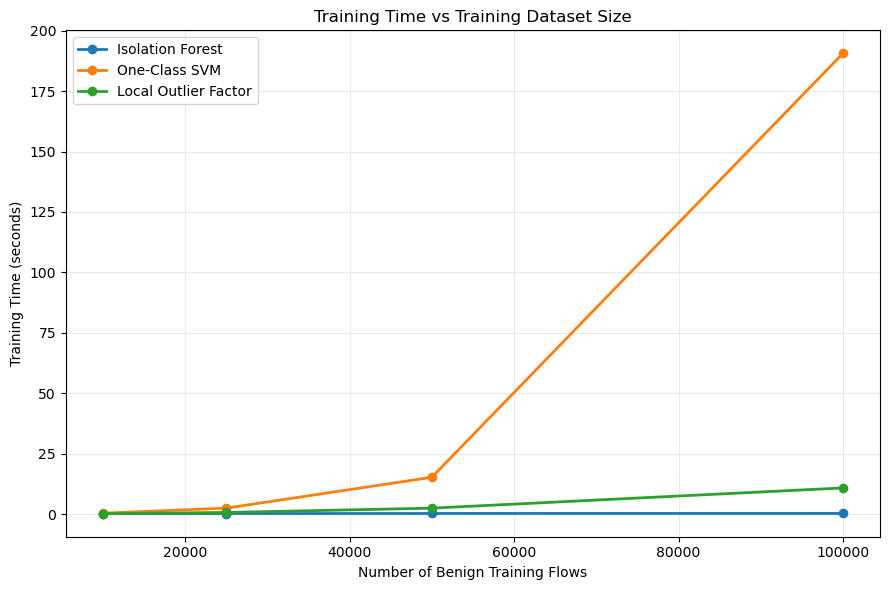


Results saved as: scalability_training_results.csv


In [42]:
# ============================================================
# STEP 21: Scalability Experiment
# ============================================================

# This experiment measures how model training time changes as the amount of benign network traffic increases.
# This is useful because we focus on large-scale network traffic, and the three anomaly-detection algorithms have very different computational requirements.
# Not replacing the main 50,000-flow experiment. This is an additional scalability analysis only.


# 1. Defining training sample sizes

# These sample sizes are large enough to show the trend while keeping the experiment practical on a normal laptop.

sample_sizes = [
    10000,
    25000,
    50000,
    100000
]


# 2. Creating a list to store timing results

scalability_results = []


# 3. Looping through each training sample size

for sample_size in sample_sizes:

    print("\n" + "=" * 60)
    print(f"Training sample size: {sample_size:,}")
    print("=" * 60)

    # Creating a reproducible benign training sample

    X_scalability_sample = (
        X_benign_train_reduced
        .sample(
            n=sample_size,
            random_state=RANDOM_STATE
        )
    )

    # Scaling using a scaler fitted only on this benign sample.
    scalability_scaler = StandardScaler()

    X_scalability_scaled = (
        scalability_scaler.fit_transform(
            X_scalability_sample
        )
    )


    # Isolation Forest timing

    print("Training Isolation Forest...")

    isolation_scale_model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    start_time = time.perf_counter()

    isolation_scale_model.fit(
        X_scalability_scaled
    )

    isolation_scale_time = (
        time.perf_counter() - start_time
    )

    print(
        f"Isolation Forest training time: "
        f"{isolation_scale_time:.2f} seconds"
    )

    scalability_results.append({
        "Model": "Isolation Forest",
        "Training Samples": sample_size,
        "Training Time (s)": isolation_scale_time
    })


    # One-Class SVM timing

    # One-Class SVM becomes much more computationally expensive as dataset size increases.
    # testing it up to 100,000 flows

    print("Training One-Class SVM...")

    ocsvm_scale_model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.05
    )

    start_time = time.perf_counter()

    ocsvm_scale_model.fit(
        X_scalability_scaled
    )

    ocsvm_scale_time = (
        time.perf_counter() - start_time
    )

    print(
        f"One-Class SVM training time: "
        f"{ocsvm_scale_time:.2f} seconds"
    )

    scalability_results.append({
        "Model": "One-Class SVM",
        "Training Samples": sample_size,
        "Training Time (s)": ocsvm_scale_time
    })


    # Local Outlier Factor timing

    print("Training Local Outlier Factor...")

    lof_scale_model = LocalOutlierFactor(
        n_neighbors=20,
        novelty=True,
        contamination="auto",
        n_jobs=-1
    )

    start_time = time.perf_counter()

    lof_scale_model.fit(
        X_scalability_scaled
    )

    lof_scale_time = (
        time.perf_counter() - start_time
    )

    print(
        f"LOF training time: "
        f"{lof_scale_time:.2f} seconds"
    )

    scalability_results.append({
        "Model": "Local Outlier Factor",
        "Training Samples": sample_size,
        "Training Time (s)": lof_scale_time
    })


# 4. Converting results into a DataFrame

scalability_df = pd.DataFrame(
    scalability_results
)


# 5. Displaying scalability table

print("\nScalability Results")
print("-------------------")

display(
    scalability_df.round({
        "Training Time (s)": 2
    })
)


# 6. Creating scalability graph

plt.figure(figsize=(9, 6))

for model_name in scalability_df["Model"].unique():

    model_data = scalability_df[
        scalability_df["Model"] == model_name
    ]

    plt.plot(
        model_data["Training Samples"],
        model_data["Training Time (s)"],
        marker="o",
        linewidth=2,
        label=model_name
    )


plt.title(
    "Training Time vs Training Dataset Size"
)

plt.xlabel("Number of Benign Training Flows")
plt.ylabel("Training Time (seconds)")

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "scalability_training_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. Saving scalability results

scalability_df.to_csv(
    "scalability_training_results.csv",
    index=False
)

print(
    "\nResults saved as: "
    "scalability_training_results.csv"
)

In [1]:
# Experimental environment information

import sys
import platform
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn

print("SYSTEM INFORMATION")
print("------------------")
print("Operating System:", platform.platform())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Python Version:", sys.version.split()[0])

print("\nLIBRARY VERSIONS")
print("----------------")
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)

SYSTEM INFORMATION
------------------
Operating System: macOS-26.5.2-arm64-arm-64bit
Machine: arm64
Processor: arm
Python Version: 3.12.4

LIBRARY VERSIONS
----------------
pandas: 2.2.2
NumPy: 1.26.4
scikit-learn: 1.4.2
Matplotlib: 3.8.4
Seaborn: 0.13.2
